# 6. Ensemble-Modelle

In diesem Notebook wird geprüft, ob eine Kombination mehrerer bereits untersuchter Modellkandidaten einen Mehrwert gegenüber dem besten Einzelmodell liefert. Die Hyperparameteroptimierung der Einzelmodelle wurde im vorherigen Notebook getrennt betrachtet. Hier wird daraus eine Ensemble-Strategie abgeleitet und mit derselben stratifizierten Cross-Validation bewertet.

Der Fokus liegt auf drei Fragen:

1. Welche getunten Einzelmodelle kommen als Ensemble-Bausteine infrage?
2. Verbessert ein Ensemble die Validierungsleistung gegenüber den Einzelmodellen?
3. Hilft das Ensemble insbesondere bei kleinen Klassen?

## 6.1. Setup und Daten laden

Zunächst werden die Trainingsdaten, die Baseline-Ergebnisse und optional die Ergebnisse aus der Hyperparameteroptimierung geladen. Der finale Testdatensatz wird hier bewusst nicht verwendet. Er bleibt für die abschließende Evaluation reserviert.

In [7]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from joblib import Memory
from tqdm.auto import tqdm

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import VotingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from model_evaluation import (
    display_model_evaluation_table,
    safe_model_filename,
)

processed_data_dir = project_root / "data" / "processed"
report_dir = project_root / "reports" / "ensemble"
report_dir.mkdir(parents=True, exist_ok=True)

sklearn_memory = Memory(
    location=project_root / "cache" / "sklearn",
    verbose=0,
)

train_df = pd.read_csv(
    processed_data_dir / "train_data.csv",
    sep=";",
    index_col=0,
    encoding="utf-8",
)

baseline_results_path = processed_data_dir / "baseline_cv_results.csv"
baseline_results = pd.read_csv(
    baseline_results_path,
    sep=";",
    encoding="utf-8",
)

optuna_results_path = processed_data_dir / "optuna_tuning_results.csv"
if optuna_results_path.exists():
    tuning_results = pd.read_csv(
        optuna_results_path,
        sep=";",
        encoding="utf-8",
    )
else:
    tuning_results = pd.DataFrame()
    print("Keine Optuna-Ergebnisse gefunden. Es werden Baseline-Parameter verwendet.")

def add_validation_metric_aliases(dataframe):
    """Ergänzt val_-Metriken für ältere Ergebnisdateien."""
    result = dataframe.copy()

    metric_names = [
        "macro_f1",
        "weighted_f1",
        "balanced_accuracy",
        "accuracy",
    ]

    for metric_name in metric_names:
        for suffix in ["mean", "std"]:
            val_column = f"val_{metric_name}_{suffix}"
            test_column = f"test_{metric_name}_{suffix}"
            plain_column = f"{metric_name}_{suffix}"

            if val_column in result.columns:
                continue

            if test_column in result.columns:
                result[val_column] = result[test_column]
            elif plain_column in result.columns:
                result[val_column] = result[plain_column]

    return result


baseline_results = add_validation_metric_aliases(baseline_results)
tuning_results = add_validation_metric_aliases(tuning_results)

print("Trainingsdaten:", train_df.shape)
print("Baseline-Ergebnisse:", baseline_results.shape)
print("Tuning-Ergebnisse:", tuning_results.shape)

Trainingsdaten: (45920, 28)
Baseline-Ergebnisse: (7, 40)
Tuning-Ergebnisse: (92, 42)


## 6.2. Modellspalten und Vorverarbeitung

Die Ensemble-Modelle verwenden dieselbe Vorverarbeitung wie die klassischen Baseline-Modelle: Textspalten werden mit TF-IDF verarbeitet, `art_standardised` und `jahr` werden One-Hot-codiert und `betrag` wird skaliert. Dadurch bleibt der Vergleich zwischen Einzelmodellen und Ensembles methodisch konsistent.

In [8]:
target_column = "politikbereich"

text_features = [
    "name_standardised",
    "geber_standardised",
    "anschrift_standardised",
    "zweck_standardised",
]

numeric_features = [
    "betrag",
]

categorical_features = [
    "art_standardised",
    "jahr",
]

feature_columns = text_features + numeric_features + categorical_features

X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].copy()


def flatten_column(values):
    return np.asarray(values, dtype=object).ravel()


text_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="",
            ),
        ),
        (
            "flatten",
            FunctionTransformer(
                flatten_column,
                validate=False,
            ),
        ),
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                min_df=3,
                max_df=0.90,
                ngram_range=(1, 2),
                sublinear_tf=True,
                max_features=30_000,
                dtype=np.float32,
            ),
        ),
    ]
)

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore"),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            f"tfidf_{column}",
            text_transformer,
            [column],
        )
        for column in text_features
    ]
    + [
        (
            "numeric",
            numeric_transformer,
            numeric_features,
        )
    ]
    + [
        (
            "categorical",
            categorical_transformer,
            categorical_features,
        )
    ],
    remainder="drop",
)

min_class_count = y_train.value_counts().min()
n_splits = min(4, min_class_count)

cv = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42,
)

scoring = {
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
    "balanced_accuracy": "balanced_accuracy",
    "accuracy": "accuracy",
}

print("CV-Folds:", n_splits)
print("Feature-Spalten:", feature_columns)

CV-Folds: 4
Feature-Spalten: ['name_standardised', 'geber_standardised', 'anschrift_standardised', 'zweck_standardised', 'betrag', 'art_standardised', 'jahr']


## 6.3. Einzelmodelle als Vergleichsbasis

Bevor ein Ensemble bewertet wird, werden die stärksten Einzelmodelle aus Baseline und Hyperparameteroptimierung eingeordnet. Für die Auswahl ist `val_macro_f1_mean` die wichtigste Metrik, weil sie alle Klassen gleich gewichtet und dadurch Probleme bei kleinen Klassen sichtbar macht.

In [9]:
baseline_display = display_model_evaluation_table(
    baseline_results,
    model_column_candidates=[
        "Modell",
    ],
    include_columns=[
        "CV_Folds",
    ],
    metric_prefixes=[
        "train_",
        "val_",
    ],
    sort_by="val_macro_f1_mean",
    ascending=False,
)

if not tuning_results.empty:
    tuning_display = display_model_evaluation_table(
        tuning_results,
        model_column_candidates=[
            "Modell",
        ],
        include_columns=[
            "trial_number",
            "objective_value",
            "penalty",
            "alpha",
            "l1_ratio",
            "C",
            "class_weight",
            "max_iter",
            "tol",
            "average",
        ],
        metric_prefixes=[
            "train_",
            "val_",
        ],
        sort_by="val_macro_f1_mean",
        ascending=False,
    )
else:
    tuning_display = pd.DataFrame()

,Modell,CV_Folds,val_macro_f1_mean,val_macro_f1_std,train_macro_f1_mean,train_macro_f1_std,val_weighted_f1_mean,val_weighted_f1_std,train_weighted_f1_mean,train_weighted_f1_std,val_balanced_accuracy_mean,val_balanced_accuracy_std,train_balanced_accuracy_mean,train_balanced_accuracy_std,val_accuracy_mean,val_accuracy_std,train_accuracy_mean,train_accuracy_std,fit_time_total_seconds
0,Linear SVC unweighted,4,0.8233,0.0189,0.9419,0.0014,0.9251,0.0015,0.9711,0.0003,0.7945,0.0226,0.9186,0.0027,0.9267,0.0014,0.9714,0.0003,97.31
1,Linear SVC balanced,4,0.8145,0.0072,0.9267,0.0046,0.9137,0.0009,0.9536,0.0002,0.8429,0.0142,0.9647,0.0007,0.9123,0.0009,0.9529,0.0003,114.17
2,SGD hinge balanced,4,0.8064,0.0326,0.9119,0.0221,0.9198,0.0036,0.9639,0.0038,0.8382,0.0215,0.9607,0.0166,0.9179,0.0050,0.9627,0.0052,12.69
3,SGD log loss balanced,4,0.7790,0.0103,0.8721,0.0070,0.8828,0.0042,0.9142,0.0032,0.8162,0.0099,0.9283,0.0087,0.8789,0.0051,0.9113,0.0038,14.01
4,Complement Naive Bayes text only,4,0.6169,0.0079,0.7024,0.0107,0.8459,0.0020,0.8870,0.0008,0.5787,0.0073,0.6542,0.0077,0.8563,0.0021,0.8934,0.0007,13.09
5,Logistic Regression balanced,4,0.6135,0.0196,0.6599,0.0243,0.7324,0.0151,0.7444,0.0154,0.7471,0.0057,0.8194,0.0112,0.7235,0.0152,0.7366,0.0152,54.29
6,Dummy Classifier,4,0.0103,0.0000,0.0103,0.0000,0.0653,0.0000,0.0653,0.0000,0.0312,0.0000,0.0312,0.0000,0.1977,0.0000,0.1977,0.0000,0.09


,Modell,trial_number,objective_value,penalty,alpha,l1_ratio,C,max_iter,tol,average,train_accuracy_mean,train_accuracy_std,train_balanced_accuracy_mean,train_balanced_accuracy_std,train_macro_f1_mean,train_macro_f1_std,train_weighted_f1_mean,train_weighted_f1_std,val_accuracy_mean,val_accuracy_std,val_balanced_accuracy_mean,val_balanced_accuracy_std,val_macro_f1_mean,val_macro_f1_std,val_weighted_f1_mean,val_weighted_f1_std,fit_time_total_seconds
0,Linear SVC unweighted,6,0.8575,NaN,NaN,NaN,0.425808,30000,0.0005,NaN,0.9931,0.0002,0.9829,0.0012,0.9864,0.0007,0.9931,0.0002,0.9425,0.0011,0.8415,0.0211,0.8575,0.0142,0.9418,0.0011,16.13
1,Linear SVC unweighted,12,0.8571,NaN,NaN,NaN,0.489375,30000,0.0010,NaN,0.9936,0.0002,0.9842,0.0011,0.9872,0.0005,0.9936,0.0002,0.9431,0.0009,0.8415,0.0191,0.8571,0.0134,0.9425,0.0008,16.79
2,Linear SVC unweighted,13,0.8563,NaN,NaN,NaN,0.475852,30000,0.0005,NaN,0.9935,0.0002,0.9838,0.0013,0.9870,0.0007,0.9935,0.0002,0.9429,0.0007,0.8405,0.0191,0.8563,0.0133,0.9422,0.0007,18.10
3,Linear SVC unweighted,11,0.8563,NaN,NaN,NaN,0.475700,30000,0.0010,NaN,0.9935,0.0002,0.9838,0.0013,0.9870,0.0007,0.9935,0.0002,0.9429,0.0007,0.8405,0.0191,0.8563,0.0133,0.9422,0.0007,15.19
4,Linear SVC unweighted,18,0.8563,NaN,NaN,NaN,0.475115,30000,0.0010,NaN,0.9935,0.0002,0.9838,0.0013,0.9870,0.0007,0.9935,0.0002,0.9429,0.0007,0.8405,0.0191,0.8563,0.0133,0.9422,0.0007,20.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,Linear SVC balanced,4,0.7437,NaN,NaN,NaN,0.013725,20000,0.0010,NaN,0.8983,0.0006,0.9143,0.0013,0.8336,0.0091,0.9004,0.0005,0.8676,0.0023,0.7988,0.0098,0.7437,0.0060,0.8700,0.0019,16.19
88,SGD hinge,0,0.6747,elasticnet,0.000157,0.486459,NaN,1000,0.0010,False,0.8288,0.0055,0.8313,0.0062,0.7323,0.0053,0.8263,0.0058,0.8122,0.0070,0.7504,0.0223,0.6747,0.0049,0.8101,0.0068,9.77
89,SGD hinge,3,0.6747,elasticnet,0.000157,0.486459,NaN,1000,0.0010,False,0.8288,0.0055,0.8313,0.0062,0.7323,0.0053,0.8263,0.0058,0.8122,0.0070,0.7504,0.0223,0.6747,0.0049,0.8101,0.0068,9.10
90,SGD hinge,15,0.6204,elasticnet,0.000789,0.051328,NaN,2000,0.0001,False,0.8360,0.0046,0.8159,0.0066,0.6807,0.0118,0.8415,0.0023,0.8158,0.0066,0.7266,0.0143,0.6204,0.0062,0.8216,0.0041,12.78


## 6.4. Getunte Modellparameter extrahieren

Für das Ensemble werden drei lineare Modelle betrachtet: `Linear SVC unweighted`, `Linear SVC balanced` und `SGD hinge balanced`. Wenn Tuning-Ergebnisse vorhanden sind, werden die jeweils besten Parameter pro Modell übernommen. Falls noch keine Tuning-Ergebnisse vorliegen, werden robuste Baseline-Parameter verwendet.

In [10]:
def get_best_tuning_row(model_name):
    if tuning_results.empty or "Modell" not in tuning_results.columns:
        return None

    model_rows = tuning_results.loc[
        tuning_results["Modell"].eq(model_name)
    ].copy()

    if model_rows.empty:
        return None

    sort_column = (
        "val_macro_f1_mean"
        if "val_macro_f1_mean" in model_rows.columns
        else "objective_value"
    )

    return (
        model_rows
        .sort_values(sort_column, ascending=False)
        .iloc[0]
    )


def to_bool(value, default=False):
    if pd.isna(value):
        return default

    if isinstance(value, bool):
        return value

    if isinstance(value, (int, float, np.integer, np.floating)):
        return bool(value)

    return str(value).strip().lower() in [
        "true",
        "1",
        "yes",
        "ja",
    ]


def value_or_default(row, column, default):
    if row is None:
        return default

    if column not in row.index or pd.isna(row[column]):
        return default

    return row[column]


sgd_hinge_row = get_best_tuning_row("SGD hinge")
linear_svc_unweighted_row = get_best_tuning_row("Linear SVC unweighted")
linear_svc_balanced_row = get_best_tuning_row("Linear SVC balanced")

selected_parameter_rows = []

for model_name, row in [
    ("SGD hinge balanced", sgd_hinge_row),
    ("Linear SVC unweighted", linear_svc_unweighted_row),
    ("Linear SVC balanced", linear_svc_balanced_row),
]:
    selected_parameter_rows.append(
        {
            "Modell": model_name,
            "Quelle": "Optuna" if row is not None else "Baseline-Fallback",
            "val_macro_f1_mean": value_or_default(row, "val_macro_f1_mean", np.nan),
            "objective_value": value_or_default(row, "objective_value", np.nan),
            "C": value_or_default(row, "C", np.nan),
            "alpha": value_or_default(row, "alpha", np.nan),
            "penalty": value_or_default(row, "penalty", np.nan),
            "l1_ratio": value_or_default(row, "l1_ratio", np.nan),
            "max_iter": value_or_default(row, "max_iter", np.nan),
            "tol": value_or_default(row, "tol", np.nan),
            "average": value_or_default(row, "average", np.nan),
        }
    )

selected_parameter_table = pd.DataFrame(selected_parameter_rows)
display(selected_parameter_table)

,Modell,Quelle,val_macro_f1_mean,objective_value,C,alpha,penalty,l1_ratio,max_iter,tol,average
0,SGD hinge balanced,Optuna,0.8523,0.8523,NaN,0.000012,l2,NaN,2000,0.0001,False
1,Linear SVC unweighted,Optuna,0.8575,0.8575,0.425808,NaN,NaN,NaN,30000,0.0005,NaN
2,Linear SVC balanced,Optuna,0.8516,0.8516,0.298967,NaN,NaN,NaN,10000,0.0001,NaN


## 6.5. Ensemble-Basismodelle definieren

Die drei Basismodelle sind absichtlich ähnlich, aber nicht identisch. Das ungewichtete `LinearSVC` ist häufig präziser und stabiler. Die gewichtete `LinearSVC` berücksichtigt kleine Klassen stärker. `SGDClassifier(loss="hinge")` ist eine schnelle SVM-nahe Variante und kann durch sein anderes Optimierungsverfahren ein leicht anderes Fehlerprofil erzeugen.

In [11]:
MODEL_N_JOBS = 1

sgd_hinge_params = {
    "loss": "hinge",
    "penalty": str(value_or_default(sgd_hinge_row, "penalty", "l2")),
    "alpha": float(value_or_default(sgd_hinge_row, "alpha", 1e-4)),
    "class_weight": "balanced",
    "max_iter": int(value_or_default(sgd_hinge_row, "max_iter", 1000)),
    "tol": float(value_or_default(sgd_hinge_row, "tol", 1e-3)),
    "average": to_bool(value_or_default(sgd_hinge_row, "average", False)),
    "random_state": 42,
    "n_jobs": MODEL_N_JOBS,
}

if sgd_hinge_params["penalty"] == "elasticnet":
    sgd_hinge_params["l1_ratio"] = float(
        value_or_default(sgd_hinge_row, "l1_ratio", 0.15)
    )

linear_svc_unweighted_params = {
    "class_weight": None,
    "C": float(value_or_default(linear_svc_unweighted_row, "C", 0.1)),
    "max_iter": int(value_or_default(linear_svc_unweighted_row, "max_iter", 20000)),
    "tol": float(value_or_default(linear_svc_unweighted_row, "tol", 1e-3)),
    "dual": "auto",
    "random_state": 42,
}

linear_svc_balanced_params = {
    "class_weight": "balanced",
    "C": float(value_or_default(linear_svc_balanced_row, "C", 0.05)),
    "max_iter": int(value_or_default(linear_svc_balanced_row, "max_iter", 30000)),
    "tol": float(value_or_default(linear_svc_balanced_row, "tol", 1e-3)),
    "dual": "auto",
    "random_state": 42,
}

base_models = {
    "Linear SVC unweighted tuned": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                LinearSVC(**linear_svc_unweighted_params),
            ),
        ],
        memory=sklearn_memory,
    ),
    "Linear SVC balanced tuned": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                LinearSVC(**linear_svc_balanced_params),
            ),
        ],
        memory=sklearn_memory,
    ),
    "SGD hinge balanced tuned": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                SGDClassifier(**sgd_hinge_params),
            ),
        ],
        memory=sklearn_memory,
    ),
}

base_model_overview = pd.DataFrame(
    [
        {
            "Modell": model_name,
            "Classifier": model.named_steps["classifier"].__class__.__name__,
            "Parameter": model.named_steps["classifier"].get_params(),
        }
        for model_name, model in base_models.items()
    ]
)

display(base_model_overview)

,Modell,Classifier,Parameter
0,Linear SVC unweighted tuned,LinearSVC,"{'C': 0.42580847142947, 'class_weight': None, 'dual': 'auto', 'fit_intercept': True, 'intercept_scaling': 1, 'loss': 'squared_hinge', 'max_iter': 30000, 'multi_class': 'ovr', 'penalty': 'l2', 'random_state': 42, 'tol': 0.0005, 'verbose': 0}"
1,Linear SVC balanced tuned,LinearSVC,"{'C': 0.2989667485750661, 'class_weight': 'balanced', 'dual': 'auto', 'fit_intercept': True, 'intercept_scaling': 1, 'loss': 'squared_hinge', 'max_iter': 10000, 'multi_class': 'ovr', 'penalty': 'l2', 'random_state': 42, 'tol': 0.0001, 'verbose': 0}"
2,SGD hinge balanced tuned,SGDClassifier,"{'alpha': 1.223155573916477e-05, 'average': False, 'class_weight': 'balanced', 'early_stopping': False, 'epsilon': 0.1, 'eta0': 0.0, 'fit_intercept': True, 'l1_ratio': 0.15, 'learning_rate': 'optimal', 'loss': 'hinge', 'max_iter': 2000, 'n_iter_no_change': 5, 'n_jobs': 1, 'penalty': 'l2', 'power_t': 0.5, 'random_state': 42, 'shuffle': True, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}"


## 6.6. Ensemble-Kandidaten definieren

Da `LinearSVC` keine Wahrscheinlichkeiten liefert, wird hier Hard Voting verwendet. Soft Voting wäre erst sinnvoll, wenn die Entscheidungswerte oder Wahrscheinlichkeiten der Modelle sauber kalibriert wurden. Es werden zwei einfache Varianten geprüft: eine ausgewogene Variante und eine Variante, die die beiden klassengewichteten Modelle stärker berücksichtigt.

In [12]:
ensemble_candidates = {
    "Hard Voting tuned balanced mix": VotingClassifier(
        estimators=[
            (
                "linear_svc_unweighted",
                clone(base_models["Linear SVC unweighted tuned"]),
            ),
            (
                "linear_svc_balanced",
                clone(base_models["Linear SVC balanced tuned"]),
            ),
            (
                "sgd_hinge_balanced",
                clone(base_models["SGD hinge balanced tuned"]),
            ),
        ],
        voting="hard",
        weights=[
            1.0,
            1.0,
            1.0,
        ],
        n_jobs=1,
    ),
    "Hard Voting tuned rare-class focus": VotingClassifier(
        estimators=[
            (
                "linear_svc_unweighted",
                clone(base_models["Linear SVC unweighted tuned"]),
            ),
            (
                "linear_svc_balanced",
                clone(base_models["Linear SVC balanced tuned"]),
            ),
            (
                "sgd_hinge_balanced",
                clone(base_models["SGD hinge balanced tuned"]),
            ),
        ],
        voting="hard",
        weights=[
            1.0,
            1.5,
            1.5,
        ],
        n_jobs=1,
    ),
}

ensemble_overview = pd.DataFrame(
    [
        {
            "Ensemble": ensemble_name,
            "Voting": ensemble.voting,
            "Gewichte": ensemble.weights,
            "Basismodelle": ", ".join(
                name for name, _ in ensemble.estimators
            ),
        }
        for ensemble_name, ensemble in ensemble_candidates.items()
    ]
)

display(ensemble_overview)

,Ensemble,Voting,Gewichte,Basismodelle
0,Hard Voting tuned balanced mix,hard,"[1.0, 1.0, 1.0]","linear_svc_unweighted, linear_svc_balanced, sgd_hinge_balanced"
1,Hard Voting tuned rare-class focus,hard,"[1.0, 1.5, 1.5]","linear_svc_unweighted, linear_svc_balanced, sgd_hinge_balanced"


## 6.7. Cross-Validation der Ensemble-Kandidaten

Die Ensemble-Kandidaten werden mit derselben stratifizierten Cross-Validation bewertet wie die Einzelmodelle. Ergebnisse werden gespeichert und bei erneutem Ausführen wiederverwendet, damit das Notebook nicht unnötig lange erneut trainiert.

In [13]:
RUN_ENSEMBLE_CV = globals().get("RUN_ENSEMBLE_CV", True)

ensemble_results_path = report_dir / "ensemble_cv_results.csv"

if ensemble_results_path.exists():
    ensemble_results = pd.read_csv(
        ensemble_results_path,
        sep=";",
        encoding="utf-8",
    )
else:
    ensemble_results = pd.DataFrame()

existing_ensemble_names = (
    set(ensemble_results["Modell"])
    if not ensemble_results.empty and "Modell" in ensemble_results.columns
    else set()
)

new_ensemble_rows = []

for ensemble_name, ensemble_model in tqdm(
    ensemble_candidates.items(),
    desc="Ensemble-CV",
):
    if ensemble_name in existing_ensemble_names:
        print("Verwende gespeichertes Ensemble-Ergebnis:", ensemble_name)
        continue

    if not RUN_ENSEMBLE_CV:
        print("Überspringe Ensemble-CV:", ensemble_name)
        continue

    start_time = time.perf_counter()

    cv_results = cross_validate(
        ensemble_model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=True,
    )

    row = {
        "Modell": ensemble_name,
        "Modelltyp": "Ensemble",
        "CV_Folds": n_splits,
        "fit_time_total_seconds": round(
            sum(cv_results["fit_time"]),
            2,
        ),
        "wall_time_seconds": round(
            time.perf_counter() - start_time,
            2,
        ),
    }

    for metric_name in scoring.keys():
        row[f"val_{metric_name}_mean"] = cv_results[
            f"test_{metric_name}"
        ].mean()
        row[f"val_{metric_name}_std"] = cv_results[
            f"test_{metric_name}"
        ].std(ddof=0)
        row[f"train_{metric_name}_mean"] = cv_results[
            f"train_{metric_name}"
        ].mean()
        row[f"train_{metric_name}_std"] = cv_results[
            f"train_{metric_name}"
        ].std(ddof=0)
        row[f"generalization_gap_{metric_name}"] = (
            row[f"train_{metric_name}_mean"]
            - row[f"val_{metric_name}_mean"]
        )

    new_ensemble_rows.append(row)

if new_ensemble_rows:
    ensemble_results = pd.concat(
        [
            ensemble_results,
            pd.DataFrame(new_ensemble_rows),
        ],
        ignore_index=True,
    )

ensemble_results = (
    ensemble_results
    .drop_duplicates(
        subset=["Modell"],
        keep="last",
    )
    .sort_values(
        "val_macro_f1_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

if not ensemble_results.empty:
    ensemble_results.to_csv(
        ensemble_results_path,
        index=False,
        sep=";",
        encoding="utf-8",
    )

    display_model_evaluation_table(
        ensemble_results,
        model_column_candidates=[
            "Modell",
        ],
        include_columns=[
            "Modelltyp",
            "CV_Folds",
            "fit_time_total_seconds",
        ],
        metric_prefixes=[
            "train_",
            "val_",
        ],
        sort_by="val_macro_f1_mean",
        ascending=False,
    )
else:
    print("Keine Ensemble-Ergebnisse vorhanden.")

Ensemble-CV:   0%|          | 0/2 [00:00<?, ?it/s]

d:\toydev\schwarz-test\.venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\toydev\schwarz-test\.venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\toydev\schwarz-test\.venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\toydev\schwarz-test\.venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\toydev\schwarz-test\.venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\toydev\schwarz-test\.venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to conver

,Modell,Modelltyp,CV_Folds,fit_time_total_seconds,val_macro_f1_mean,val_macro_f1_std,train_macro_f1_mean,train_macro_f1_std,val_weighted_f1_mean,val_weighted_f1_std,train_weighted_f1_mean,train_weighted_f1_std,val_balanced_accuracy_mean,val_balanced_accuracy_std,train_balanced_accuracy_mean,train_balanced_accuracy_std,val_accuracy_mean,val_accuracy_std,train_accuracy_mean,train_accuracy_std
0,Hard Voting tuned balanced mix,Ensemble,4,836.88,0.858101,0.00499,0.983990,0.001444,0.940605,0.001393,0.990147,0.000502,0.857445,0.009493,0.991574,0.00068,0.940592,0.001521,0.990099,0.000510
1,Hard Voting tuned rare-class focus,Ensemble,4,952.34,0.857935,0.00465,0.983906,0.001456,0.940515,0.001510,0.990054,0.000481,0.857500,0.009121,0.991548,0.00068,0.940483,0.001628,0.990004,0.000489


## 6.8. Vergleich mit Einzelmodellen

Ein Ensemble ist nur sinnvoll, wenn es gegenüber starken Einzelmodellen einen messbaren Nutzen bringt oder ein robusteres Fehlerprofil liefert. Deshalb werden die Ensemble-Ergebnisse gemeinsam mit Baseline- und Tuning-Ergebnissen betrachtet.

In [14]:
comparison_frames = [
    baseline_results.assign(
        Modelltyp="Einzelmodell Baseline",
    ),
]

if not tuning_results.empty:
    comparison_frames.append(
        tuning_results.assign(
            Modelltyp="Einzelmodell getunt",
        )
    )

if not ensemble_results.empty:
    comparison_frames.append(
        ensemble_results.assign(
            Modelltyp="Ensemble",
        )
    )

comparison_results = pd.concat(
    comparison_frames,
    ignore_index=True,
)

comparison_results = (
    comparison_results
    .sort_values(
        "val_macro_f1_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

comparison_display = display_model_evaluation_table(
    comparison_results,
    model_column_candidates=[
        "Modell",
    ],
    include_columns=[
        "Modelltyp",
        "CV_Folds",
        "fit_time_total_seconds",
    ],
    metric_prefixes=[
        "train_",
        "val_",
    ],
    sort_by="val_macro_f1_mean",
    ascending=False,
)

,Modell,Modelltyp,CV_Folds,fit_time_total_seconds,val_macro_f1_mean,val_macro_f1_std,train_macro_f1_mean,train_macro_f1_std,val_weighted_f1_mean,val_weighted_f1_std,train_weighted_f1_mean,train_weighted_f1_std,val_balanced_accuracy_mean,val_balanced_accuracy_std,train_balanced_accuracy_mean,train_balanced_accuracy_std,val_accuracy_mean,val_accuracy_std,train_accuracy_mean,train_accuracy_std
0,Hard Voting tuned balanced mix,Ensemble,4.0,836.88,0.858101,0.00499,0.983990,0.001444,0.940605,0.001393,0.990147,0.000502,0.857445,0.009493,0.991574,0.00068,0.940592,0.001521,0.990099,0.000510
1,Hard Voting tuned rare-class focus,Ensemble,4.0,952.34,0.857935,0.00465,0.983906,0.001456,0.940515,0.001510,0.990054,0.000481,0.857500,0.009121,0.991548,0.00068,0.940483,0.001628,0.990004,0.000489
2,Linear SVC unweighted,Einzelmodell getunt,NaN,16.13,0.857500,0.01420,0.986400,0.000700,0.941800,0.001100,0.993100,0.000200,0.841500,0.021100,0.982900,0.00120,0.942500,0.001100,0.993100,0.000200
3,Linear SVC unweighted,Einzelmodell getunt,NaN,16.79,0.857100,0.01340,0.987200,0.000500,0.942500,0.000800,0.993600,0.000200,0.841500,0.019100,0.984200,0.00110,0.943100,0.000900,0.993600,0.000200
4,Linear SVC unweighted,Einzelmodell getunt,NaN,15.19,0.856300,0.01330,0.987000,0.000700,0.942200,0.000700,0.993500,0.000200,0.840500,0.019100,0.983800,0.00130,0.942900,0.000700,0.993500,0.000200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,SGD hinge,Einzelmodell getunt,NaN,12.78,0.620400,0.00620,0.680700,0.011800,0.821600,0.004100,0.841500,0.002300,0.726600,0.014300,0.815900,0.00660,0.815800,0.006600,0.836000,0.004600
97,Complement Naive Bayes text only,Einzelmodell Baseline,4.0,13.09,0.616900,0.00790,0.702400,0.010700,0.845900,0.002000,0.887000,0.000800,0.578700,0.007300,0.654200,0.00770,0.856300,0.002100,0.893400,0.000700
98,Logistic Regression balanced,Einzelmodell Baseline,4.0,54.29,0.613500,0.01960,0.659900,0.024300,0.732400,0.015100,0.744400,0.015400,0.747100,0.005700,0.819400,0.01120,0.723500,0.015200,0.736600,0.015200
99,SGD hinge,Einzelmodell getunt,NaN,11.19,0.071900,0.01870,0.071200,0.016500,0.005600,0.001200,0.004000,0.001100,0.113900,0.013100,0.120400,0.00760,0.006100,0.001000,0.004200,0.001000


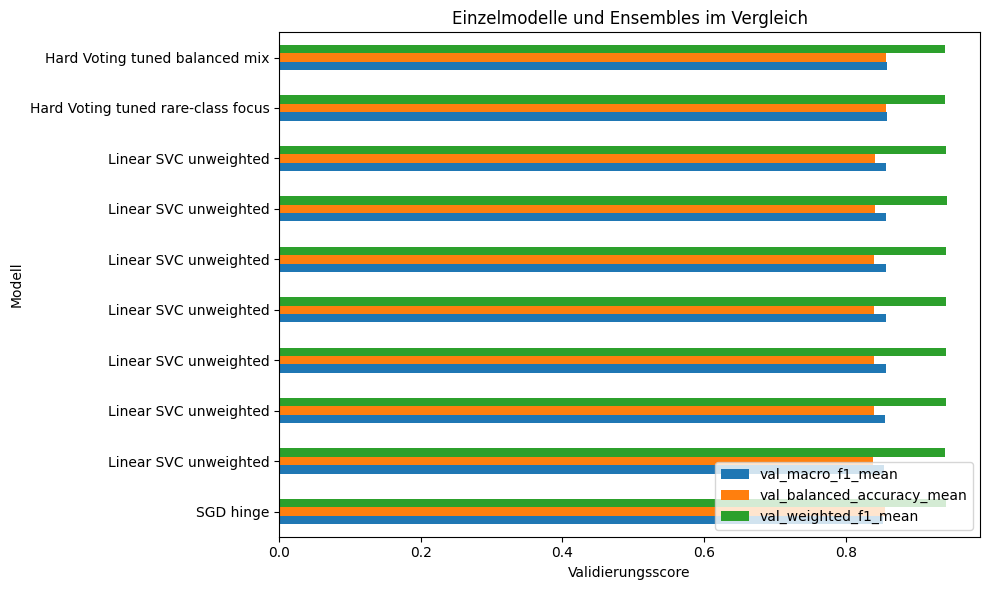

In [15]:
plot_columns = [
    "val_macro_f1_mean",
    "val_balanced_accuracy_mean",
    "val_weighted_f1_mean",
]

plot_df = (
    comparison_results
    .head(10)
    .set_index("Modell")[plot_columns]
    .sort_values("val_macro_f1_mean", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
plot_df.plot(
    kind="barh",
    ax=ax,
)
ax.set_title("Einzelmodelle und Ensembles im Vergleich")
ax.set_xlabel("Validierungsscore")
ax.set_ylabel("Modell")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 6.9. Rare-Class-Prüfung

Neben der Gesamtmetrik wird geprüft, ob das beste Ensemble bei kleinen Klassen hilft. Dafür werden Out-of-Fold-Vorhersagen erzeugt und daraus Classification Reports berechnet. Als kleine Klassen gelten hier Politikbereiche mit weniger als 100 Beobachtungen im Trainingsdatensatz.

In [16]:
rare_support_threshold = 100

class_support = (
    y_train
    .value_counts()
    .rename_axis("politikbereich")
    .reset_index(name="support")
)

rare_classes = class_support.loc[
    class_support["support"] < rare_support_threshold,
    "politikbereich",
].tolist()

print(
    f"Anzahl kleiner Klassen mit support < {rare_support_threshold}:",
    len(rare_classes),
)

display(
    class_support
    .query("politikbereich in @rare_classes")
    .sort_values("support")
)

Anzahl kleiner Klassen mit support < 100: 7


,politikbereich,support
31,Berlin-Image,4
30,Tierschutz,7
29,Finanzen,14
28,Medien,15
27,Internationales,22
26,"Bauen, Wohnen",83
25,Europa,85


In [17]:
def create_report_from_predictions(y_true, y_pred, model_name):
    report = pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            output_dict=True,
            zero_division=0,
        )
    ).transpose()

    report = (
        report
        .rename_axis("politikbereich")
        .reset_index()
    )
    report["Modell"] = model_name

    return report


def report_path_for_model(model_name):
    return (
        report_dir
        / f"classification_report_{safe_model_filename(model_name)}.csv"
    )


RUN_RARE_CLASS_REPORTS = globals().get("RUN_RARE_CLASS_REPORTS", True)

report_models = {}
report_models.update(base_models)

if not ensemble_results.empty:
    best_ensemble_name = ensemble_results.iloc[0]["Modell"]
    report_models[best_ensemble_name] = ensemble_candidates[best_ensemble_name]

classification_reports = []

for model_name, model in tqdm(
    report_models.items(),
    desc="Classification Reports",
):
    report_path = report_path_for_model(model_name)

    if report_path.exists():
        report = pd.read_csv(
            report_path,
            sep=";",
            encoding="utf-8",
        )
    elif RUN_RARE_CLASS_REPORTS:
        y_pred = cross_val_predict(
            model,
            X_train,
            y_train,
            cv=cv,
            n_jobs=1,
        )
        report = create_report_from_predictions(
            y_train,
            y_pred,
            model_name,
        )
        report.to_csv(
            report_path,
            index=False,
            sep=";",
            encoding="utf-8",
        )
    else:
        continue

    classification_reports.append(report)

classification_report_all = pd.concat(
    classification_reports,
    ignore_index=True,
)

rare_class_report = classification_report_all.loc[
    classification_report_all["politikbereich"].isin(rare_classes)
].copy()

rare_model_summary = (
    rare_class_report
    .groupby("Modell")
    .agg(
        rare_classes=("politikbereich", "nunique"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
        mean_f1=("f1-score", "mean"),
    )
    .reset_index()
    .sort_values(
        [
            "mean_f1",
            "mean_recall",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

display(rare_model_summary)

Classification Reports:   0%|          | 0/4 [00:00<?, ?it/s]

d:\toydev\schwarz-test\.venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\toydev\schwarz-test\.venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\toydev\schwarz-test\.venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\toydev\schwarz-test\.venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\toydev\schwarz-test\.venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\toydev\schwarz-test\.venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to conver

,Modell,rare_classes,mean_precision,mean_recall,mean_f1
0,Hard Voting tuned balanced mix,7,0.757298,0.754770,0.749369
1,Linear SVC unweighted tuned,7,0.803053,0.707426,0.744409
2,Linear SVC balanced tuned,7,0.724594,0.755101,0.731395
3,SGD hinge balanced tuned,7,0.695527,0.726577,0.687692


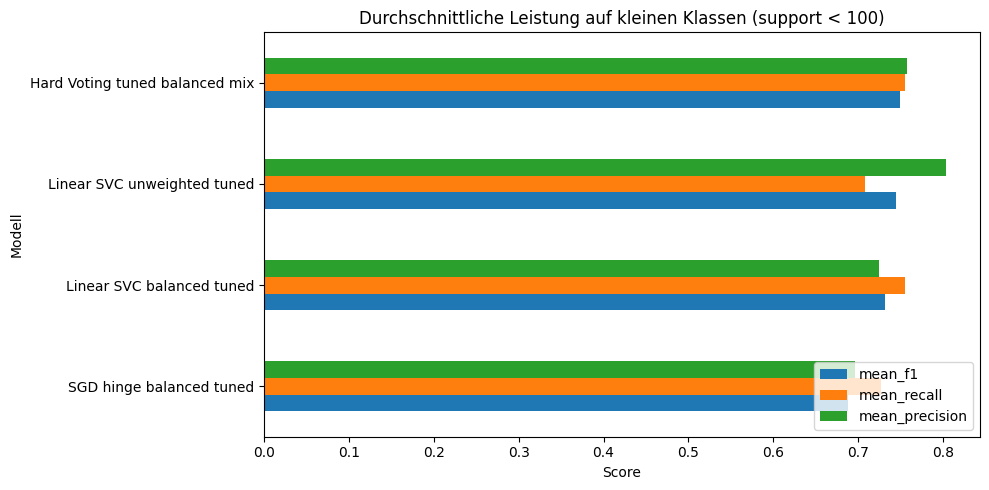

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

rare_model_summary_plot = (
    rare_model_summary
    .set_index("Modell")
    [["mean_f1", "mean_recall", "mean_precision"]]
    .sort_values("mean_f1", ascending=True)
)

rare_model_summary_plot.plot(
    kind="barh",
    ax=ax,
)

ax.set_title(
    f"Durchschnittliche Leistung auf kleinen Klassen "
    f"(support < {rare_support_threshold})"
)
ax.set_xlabel("Score")
ax.set_ylabel("Modell")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 6.10. Empfehlung

Ein Ensemble wird nur empfohlen, wenn es gegenüber dem besten Einzelmodell entweder eine bessere Macro-F1-Leistung erreicht oder bei kleinen Klassen ein stabileres Fehlerprofil zeigt. Falls das beste Einzelmodell weiterhin klar vorne liegt, sollte es wegen der geringeren Komplexität bevorzugt werden. Falls das Hard-Voting-Ensemble nahe am besten Einzelmodell liegt und kleine Klassen robuster erkennt, ist es als zusätzliche Modellvariante sinnvoll.

In [19]:
best_single_model = (
    comparison_results
    .loc[comparison_results["Modelltyp"].str.contains("Einzelmodell", na=False)]
    .sort_values("val_macro_f1_mean", ascending=False)
    .iloc[0]
)

best_ensemble = (
    ensemble_results
    .sort_values("val_macro_f1_mean", ascending=False)
    .iloc[0]
    if not ensemble_results.empty
    else None
)

if best_ensemble is not None:
    macro_f1_difference = (
        best_ensemble["val_macro_f1_mean"]
        - best_single_model["val_macro_f1_mean"]
    )

    recommendation_text = (
        "Ensemble als zusätzliche Variante prüfen"
        if macro_f1_difference >= -0.01
        else "Bestes Einzelmodell bevorzugen"
    )

    recommendation = pd.DataFrame(
        [
            {
                "Empfehlung": recommendation_text,
                "Bestes Einzelmodell": best_single_model["Modell"],
                "Bestes Ensemble": best_ensemble["Modell"],
                "Differenz_Macro_F1": round(macro_f1_difference, 4),
                "Begründung": (
                    "Das Ensemble ist nur dann vorteilhaft, wenn es die "
                    "Macro-F1-Leistung hält und bei kleinen Klassen ein "
                    "robusteres Fehlerprofil zeigt."
                ),
            }
        ]
    )
else:
    recommendation = pd.DataFrame(
        [
            {
                "Empfehlung": "Bestes Einzelmodell bevorzugen",
                "Bestes Einzelmodell": best_single_model["Modell"],
                "Bestes Ensemble": pd.NA,
                "Differenz_Macro_F1": pd.NA,
                "Begründung": "Es liegen keine Ensemble-Ergebnisse vor.",
            }
        ]
    )

display(recommendation)

,Empfehlung,Bestes Einzelmodell,Bestes Ensemble,Differenz_Macro_F1,Begründung
0,Ensemble als zusätzliche Variante prüfen,Linear SVC unweighted,Hard Voting tuned balanced mix,0.0006,"Das Ensemble ist nur dann vorteilhaft, wenn es die Macro-F1-Leistung hält und bei kleinen Klassen ein robusteres Fehlerprofil zeigt."


In [20]:
from joblib import dump

ensemble_model_dir = project_root / "models" / "ensemble"
ensemble_model_dir.mkdir(
    parents=True,
    exist_ok=True,
)

best_ensemble_name = ensemble_results.iloc[0]["Modell"]
best_ensemble_model = ensemble_candidates[best_ensemble_name]

best_ensemble_model.fit(
    X_train,
    y_train,
)

best_ensemble_model_path = (
    ensemble_model_dir
    / f"{safe_model_filename(best_ensemble_name)}.joblib"
)

dump(
    best_ensemble_model,
    best_ensemble_model_path,
)

print("Gespeichertes Ensemble-Modell:", best_ensemble_model_path)

d:\toydev\schwarz-test\.venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Gespeichertes Ensemble-Modell: d:\toydev\schwarz-test\models\ensemble\hard_voting_tuned_balanced_mix.joblib
